# Deforestation info

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Basic load
df = pd.read_csv("../data/csv/8-deforestation.csv")

In [8]:
df.shape

(1162447, 4)

In [9]:
df.head()

,lon,lat,value,cause
0,107.245476,75.866745,0.0,No loss
1,107.341819,75.866745,0.0,No loss
2,107.438161,75.866745,0.0,No loss
3,107.534504,75.866745,0.0,No loss
4,107.630847,75.866745,0.0,No loss


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1162447 entries, 0 to 1162446
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   lon     1162447 non-null  float64
 1   lat     1162447 non-null  float64
 2   value   1162447 non-null  float64
 3   cause   1162447 non-null  str    
dtypes: float64(3), str(1)
memory usage: 35.5 MB


In [11]:
df.describe()

,lon,lat,value
count,1.162447e+06,1.162447e+06,1.162447e+06
mean,1.880536e+01,3.080200e+01,1.236107e+00
std,9.025516e+01,3.215649e+01,1.517665e+00
min,-1.782176e+02,-5.602627e+01,0.000000e+00
25%,-6.694194e+01,2.260999e+00,0.000000e+00
50%,2.853357e+01,4.253221e+01,0.000000e+00
75%,1.015613e+02,5.804336e+01,3.000000e+00
max,1.799841e+02,7.586674e+01,5.000000e+00


In [19]:
def plot_pie_chart(df, column, threshold=0.02):
    counts = df[column].value_counts()

    total = counts.sum()
    counts_clean = counts[counts / total >= threshold]
    counts_clean["Other"] = counts[counts / total < threshold].sum()
    if counts_clean["Other"] == 0:
        counts_clean = counts_clean.drop("Other")

    plt.figure(figsize=(8, 8))
    plt.pie(
        counts_clean,
        labels=counts_clean.index,
        autopct="%1.1f%%",
        colors=plt.cm.tab20.colors,
    )
    plt.title("Deforestation by " + column.replace("_", " ").title())
    plt.tight_layout()


plt.show()

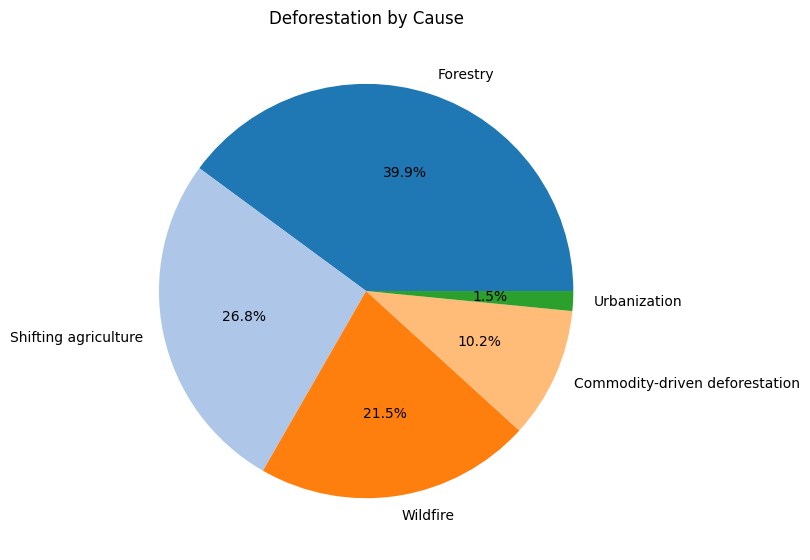

In [22]:
plot_pie_chart(df.where(df['cause'] != "No loss"), "cause", threshold=0.0)

In [ ]:
def plot_bar_chart(df, column):
    counts = df[column].value_counts() / 100
    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar", color=plt.cm.tab20.colors)
    plt.title("Deforestation by " + column.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("1'000 Km²")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

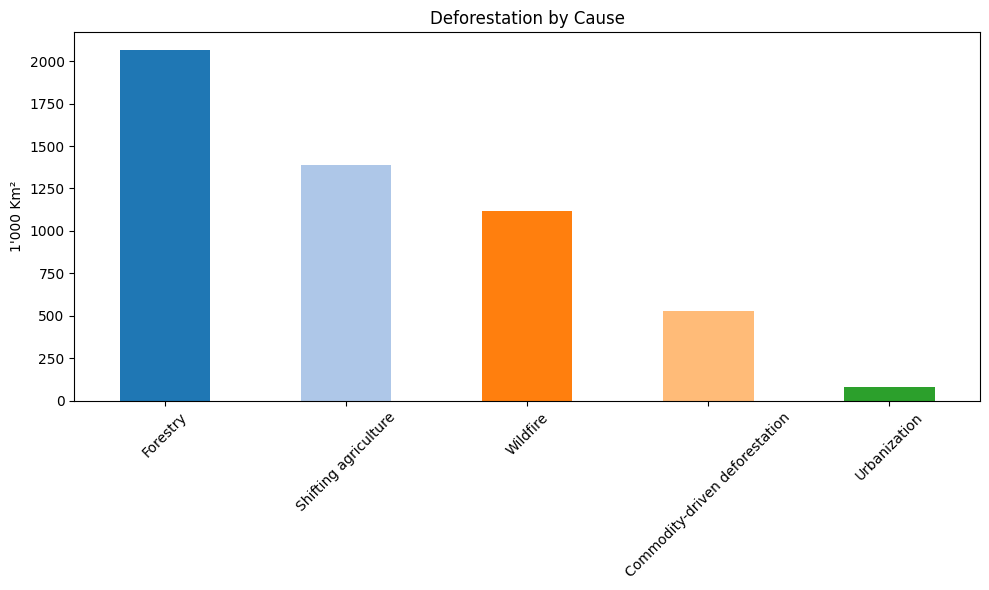

In [36]:
plot_bar_chart(df.where(df['cause'] != "No loss"), "cause")